<a href="https://colab.research.google.com/github/mteoraso/Electricity_Sector_COL_XM/blob/EDA/demanda_no_atendida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pydataxm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [2]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="bright")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
## Autocorrelacion en series de tiempo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
# Importación de API XM
from pydataxm.pydatasimem import ReadSIMEM, CatalogSIMEM
# Crear una instancia de ReadSIMEM
# Esta base de datos es sobre fallas en subestaciones de energia
dataset_id = '3C77AF'
fecha_inicio = '2020-01-01'
fecha_fin = '2024-04-30'
generacion = ReadSIMEM(dataset_id, fecha_inicio, fecha_fin)
# Recuperar datos
data = generacion.main(filter=False)
print(data)

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Eventos de Demanda No Atendida"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0015037059783935547


KeyboardInterrupt: 

In [5]:
data

,IdentificadorSuceso,FechaHoraInicio,FechaHoraFin,OrigenEvento,EnergiaNoAtendida,DescripcionEvento,CodigoSubAreaOperativa
0,S000020446,2022-08-10 22:17:00,2022-08-10 22:35:00,No programada,4200.0,Demanda no atendida por disparo del activo BL1...,Are0025
1,S000020443,2022-08-10 00:13:00,2022-08-10 12:26:00,No programada,505600.0,Demanda no atendida por disparo del activo CHI...,Are0021
2,S000020444,2022-08-10 02:14:00,2022-08-10 02:39:00,No programada,19510.0,Demanda no atendida por disparo del activo BL1...,Are0018
3,S000020445,2022-08-10 21:56:00,2022-08-10 22:11:00,No programada,5500.0,Demanda no atendida por disparo del activo BL1...,Are0018
4,S000019673,2021-11-18 00:41:00,2021-11-18 02:54:00,No programada,18180.0,Demanda no atendida por disparo del activo LA ...,Are0021
...,...,...,...,...,...,...,...
3674,S000021793,2023-10-25 18:25:00,2023-10-25 21:55:00,No programada,167400.0,Demanda no atendida por disparo del activo BL1...,Are0017
3675,S000021794,2023-10-25 21:41:00,2023-10-25 21:49:00,No programada,5510.0,Demanda no atendida por disparo del activo BL1...,Are0025
3676,S000021792,2023-10-25 06:32:00,2023-10-25 15:37:00,Programada,172670.0,Demanda no atendida por trabajos en las consig...,Are0016
3677,S000021530,2023-08-22 07:08:00,2023-08-22 16:37:00,No programada,360000.0,Demanda no atendida por disparo del activo TPE...,Are0017


# **Analisis Exploratorio de datos**

In [6]:
# Resumen estadistico de columnas numericas
data.describe()

,EnergiaNoAtendida
count,3.676000e+03
mean,6.373171e+04
std,1.276584e+05
min,7.000000e+01
25%,3.960000e+03
50%,1.559500e+04
75%,6.977750e+04
max,2.608110e+06


In [7]:
# Dimensionalidad (filas, columnas)
data.shape

(3679, 7)

In [8]:
# Columnas del DF
data.columns.to_list()

['IdentificadorSuceso',
 'FechaHoraInicio',
 'FechaHoraFin',
 'OrigenEvento',
 'EnergiaNoAtendida',
 'DescripcionEvento',
 'CodigoSubAreaOperativa']

**Limpieza y transformacion de datos**

In [9]:
# Verificamos valores nulos
data.isnull().sum()

,0
IdentificadorSuceso,3
FechaHoraInicio,0
FechaHoraFin,3
OrigenEvento,3
EnergiaNoAtendida,3
DescripcionEvento,3
CodigoSubAreaOperativa,6


In [10]:
data_copia = data.copy()
data_copia = data_copia.dropna(axis=0) # Borrar filas con registros nulos

In [11]:
# Validamos cambios realizados
data_copia.isnull().sum()

,0
IdentificadorSuceso,0
FechaHoraInicio,0
FechaHoraFin,0
OrigenEvento,0
EnergiaNoAtendida,0
DescripcionEvento,0
CodigoSubAreaOperativa,0


In [12]:
data_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3673 entries, 0 to 3678
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IdentificadorSuceso     3673 non-null   object 
 1   FechaHoraInicio         3673 non-null   object 
 2   FechaHoraFin            3673 non-null   object 
 3   OrigenEvento            3673 non-null   object 
 4   EnergiaNoAtendida       3673 non-null   float64
 5   DescripcionEvento       3673 non-null   object 
 6   CodigoSubAreaOperativa  3673 non-null   object 
dtypes: float64(1), object(6)
memory usage: 229.6+ KB


In [13]:
data_copia['FechaHoraInicio'] = data_copia['FechaHoraInicio'].astype("datetime64[ns]")
data_copia['FechaHoraFin'] = data_copia['FechaHoraFin'].astype("datetime64[ns]")
data_copia['OrigenEvento'] = data_copia['OrigenEvento'].astype("category")
data_copia['CodigoSubAreaOperativa'] = data_copia['CodigoSubAreaOperativa'].astype("category")
data_copia['IdentificadorSuceso'] = data_copia['IdentificadorSuceso'].astype("category")
data_copia['DescripcionEvento'] = data_copia['DescripcionEvento'].astype("category")
data_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3673 entries, 0 to 3678
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   IdentificadorSuceso     3673 non-null   category      
 1   FechaHoraInicio         3673 non-null   datetime64[ns]
 2   FechaHoraFin            3673 non-null   datetime64[ns]
 3   OrigenEvento            3673 non-null   category      
 4   EnergiaNoAtendida       3673 non-null   float64       
 5   DescripcionEvento       3673 non-null   category      
 6   CodigoSubAreaOperativa  3673 non-null   category      
dtypes: category(4), datetime64[ns](2), float64(1)
memory usage: 381.7 KB


In [14]:
## Identificacion de registros duplicados donde coinciden en todos los campos
print(f"El numero de registros duplicados es de: {data_copia.duplicated().sum()}")

El numero de registros duplicados es de: 0


In [15]:
## Visualizo los registros unicos de cada campo
columnas_DF = data_copia.columns
for i in columnas_DF:
  print(f"Valores unicos en la columna {i}:")  ## Nombro la columna a mostrar
  print(pd.unique(data[i]))  ## Imprimo los valores unicos de cada columna

Valores unicos en la columna IdentificadorSuceso:
['S000020446' 'S000020443' 'S000020444' ... 'S000021792' 'S000021530'
 'S000021529']
Valores unicos en la columna FechaHoraInicio:
['2022-08-10 22:17:00' '2022-08-10 00:13:00' '2022-08-10 02:14:00' ...
 '2023-10-25 06:32:00' '2023-08-22 07:08:00' '2023-08-22 00:00:00']
Valores unicos en la columna FechaHoraFin:
['2022-08-10 22:35:00' '2022-08-10 12:26:00' '2022-08-10 02:39:00' ...
 '2023-10-25 15:37:00' '2023-08-22 16:37:00' '2023-08-22 11:49:00']
Valores unicos en la columna OrigenEvento:
['No programada' 'Programada' nan]
Valores unicos en la columna EnergiaNoAtendida:
[  4200. 505600.  19510. ... 172670. 360000.  78340.]
Valores unicos en la columna DescripcionEvento:
['Demanda no atendida por disparo del activo BL1 VALLEDUPAR A CODAZZI (CESAR) 110 kV, dejando sin tensión las subestaciones radiales CODAZZI (CESAR) 110 kV y LA JAGUA 110 kV.'
 'Demanda no atendida por disparo del activo CHINU - SAN MARCOS (SUCRE) 1 110 kV, dejando sin 

In [16]:
descripciones_eventos = pd.unique(data['DescripcionEvento'])
descripciones_eventos

array(['Demanda no atendida por disparo del activo BL1 VALLEDUPAR A CODAZZI (CESAR) 110 kV, dejando sin tensión las subestaciones radiales CODAZZI (CESAR) 110 kV y LA JAGUA 110 kV.',
       'Demanda no atendida por disparo del activo CHINU - SAN MARCOS (SUCRE) 1 110 kV, dejando sin tensión las subestaciones radiales SAN MARCOS (SUCRE) 110 kV y LA MOJANA 110 kV.',
       'Demanda no atendida por disparo del activo BL1 TOLUVIEJO A EL CARMEN 110 kV, dejando sin tensión las subestaciones temporalmente radiales EL CARMEN 110 kV, ZAMBRANO 66 kV, SAN JACINTO 66 kV y CALAMAR 66 kV.',
       ...,
       'Demanda no atendida por trabajos en las consignaciones C2008743 y C2008744 de los activos BL1 BARANOA A SABANALARGA 110 kV y BARANOA 1 60 MVA 110/34.5/13.8 kV, respectivamente.',
       'Demanda no atendida por disparo del activo TPELDAR - ZIPAQUIRA 1 115 kV, dejando sin tensión las S/Es radiales UBATE 115 kV y SIMIJACA 115 kV.',
       'Continua demanda no atendida por disparo del activo CERTE

In [17]:
len(descripciones_eventos)

2867

**Identificacion de patrones y relaciones entre campos**

In [18]:
## Cantidad de eventos por categoria (Programados y no programados)
DF_origen_evento = data_copia.groupby([
    'OrigenEvento']).size().reset_index(name="Numero_eventos")
DF_origen_evento

/tmp/ipython-input-2406310588.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DF_origen_evento = data_copia.groupby([


,OrigenEvento,Numero_eventos
0,No programada,2684
1,Programada,989


In [19]:
## Cantidad de energia no atendida por origen de evento
# Sumamos la energia no atendida por evento, luego se rodondea y se ordena
DF_origen_cant = data_copia.groupby('OrigenEvento')[
    'EnergiaNoAtendida'].sum().round(20).sort_values(ascending=False)
DF_origen_cant

/tmp/ipython-input-2637259807.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DF_origen_cant = data_copia.groupby('OrigenEvento')[


,EnergiaNoAtendida
OrigenEvento,
Programada,1.442982e+08
No programada,8.990250e+07


In [20]:
## Identificacion de energia no atendida por descripcion de evento
data_copia.groupby('DescripcionEvento')[
    'EnergiaNoAtendida'].sum().sort_values(ascending=False)

/tmp/ipython-input-2413634826.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_copia.groupby('DescripcionEvento')[


,EnergiaNoAtendida
DescripcionEvento,
Se presenta DNA por evento en las subáreas Atlántico Bolívar y GCM pertenecientes al área Caribe. Debido a falla en el CT de la fase A del activo BL2 SABANALARGA A FUNDACION 220 kV adicionalmente se disparan los extremos remotos asociados a los circuitos de la subestación SABANALARGA 220 kV.,6625350.00
Continua demanda no atendida por trabajos en la consignación de emergencia C0196936 del activo SAMORE - TOLEDO 1 230 kV dejando sin tensión las subestaciones radiales SAMORE 230 kV BANADIA 230 kV y CAÑO LIMON 230 kV.,3802000.00
Continua demanda no atendida por trabajos en la consignación de emergencia C0196936 del activo SAMORE - TOLEDO 1 230 kV dejando sin tensión las subestaciones radiales SAMORE 230 kV BANADIA 230 kV y CAÑO LIMON 230 kV.,2664050.00
Continua demanda no atendida por evento en la S/E VALLEDUPAR 220 KV -110 KV-34.5 KV- 13.8 KV.,1887370.02
"Continúa demanda no atendida por disparo de los activos asociados a la barra CHINÚ 110 KV y el transformador CHINÚ 1 150 MVA 500/110/34.5 kV; dejando sin tensión las subestaciones: CHINÚ PLANTA 110 kV, SAN MARCOS (SUCRE) 110 kV, LA MOJANA 110 kV, CHINÚ PLANTA 110 kV, SINCÉ 110 kV, MAGANGUÉ 110 kV, MOMPOX 110 kV, BOSTON 110 kV, COVEÑAS 110 kV, SIERRA FLOR 110 kV, TOLUVIEJO 110 kV, EL CARMEN 110 kV, ZAMBRANO 66 kV, SAN JACINTO 66 kV y CALAMAR 66 kV.",1717050.00
...,...
Demanda no atendida por disparo de los activos asociados a la subestación CONVENCION 115 kV dejando sin tensión las subestaciones temporalmente radiales CONVENCION 115 kV y TIBU 115 kV.,1000.00
Demanda no atendida en la subestación Piedras Blancas del SDL.,1000.00
Demanda no atendida por disparo de los activos ITAGUI - EL RODEO 1 110 kV y ENVIGADO - ITAGUI 1 110 kV dejando sin tensión la S/E ITAGUI 110 kV.,1000.00


In [21]:
## Identificacion de energia no atendida y cantidad de eventos por subarea operativa
DF_subarea = data_copia.groupby('CodigoSubAreaOperativa').agg(
    TotalEnergiaNoAtendida=('EnergiaNoAtendida', 'sum'),
    CantidadRegistros=('CodigoSubAreaOperativa', 'size'),
).reset_index()

DF_subarea = DF_subarea.sort_values(by=['TotalEnergiaNoAtendida'], ascending=False)
## Ordeno valores por cantidad de energia no atendida
DF_subarea['EnergiaNoAtendidaPorRegistro'] = round(DF_subarea[
    'TotalEnergiaNoAtendida'] / DF_subarea['CantidadRegistros'], 4)

# Muestra el nuevo DataFrame
display(DF_subarea)

/tmp/ipython-input-2152957249.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DF_subarea = data_copia.groupby('CodigoSubAreaOperativa').agg(


,CodigoSubAreaOperativa,TotalEnergiaNoAtendida,CantidadRegistros,EnergiaNoAtendidaPorRegistro
8,Are0025,61760680.00,777,79486.0746
3,Are0018,47488999.96,680,69836.7646
1,Are0016,35217630.02,265,132896.7171
6,Are0021,25537110.02,336,76003.3036
4,Are0019,13093900.00,356,36780.6180
15,Are0129,10539420.00,60,175657.0000
2,Are0017,7289160.00,145,50270.0690
10,Are0027,7256139.99,170,42683.1764
9,Are0026,6918510.00,95,72826.4211
18,Are0132,4208450.00,114,36916.2281


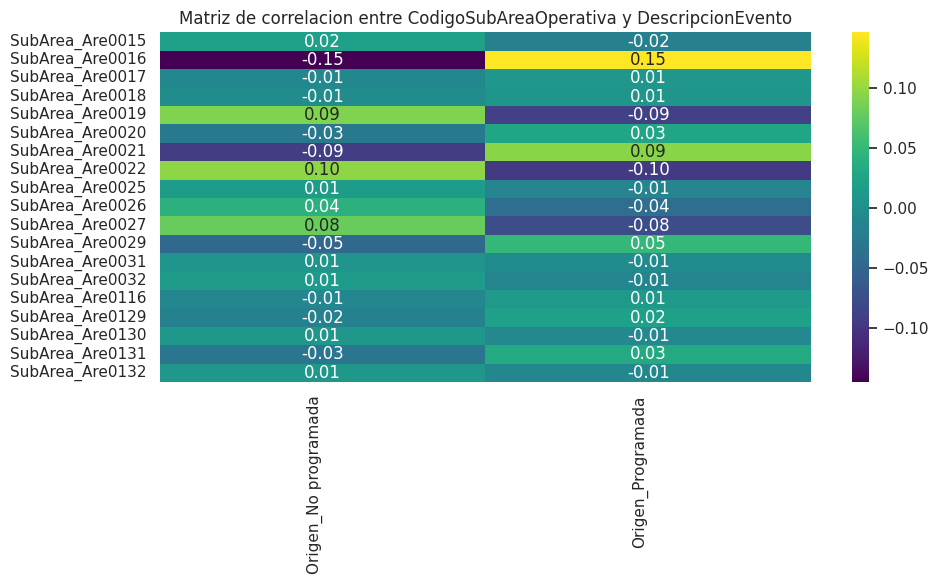

In [22]:
## Matriz de correlacion con respecto a origen Evento
# Creacion de DF
df_corr = data[['CodigoSubAreaOperativa', 'OrigenEvento']]
# Conversion en variables Dummy para colunas con variables categoricas
df_corr_dummy = pd.get_dummies(df_corr,
                               columns=['CodigoSubAreaOperativa', 'OrigenEvento'],
                               prefix=['SubArea', 'Origen'])
# Calculo de matriz de correlacion entre variables convertidas
corr = df_corr_dummy.corr()
# Reordeno para que en el eje X me quede el campo de origen Evento, y en el eje Y el codigo Subarea
subarea_cols = [col for col in corr.columns if col.startswith('SubArea')]
origen_cols = [col for col in corr.columns if col.startswith('Origen')]
corr_selected = corr.loc[subarea_cols, origen_cols]
# Creo el mapa de calor
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.heatmap(corr_selected, cmap="viridis", annot=True, fmt=".2f")  # Uso '.2f' para mostrar dos decimales en grafica
plt.title('Matriz de correlacion entre CodigoSubAreaOperativa y DescripcionEvento')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

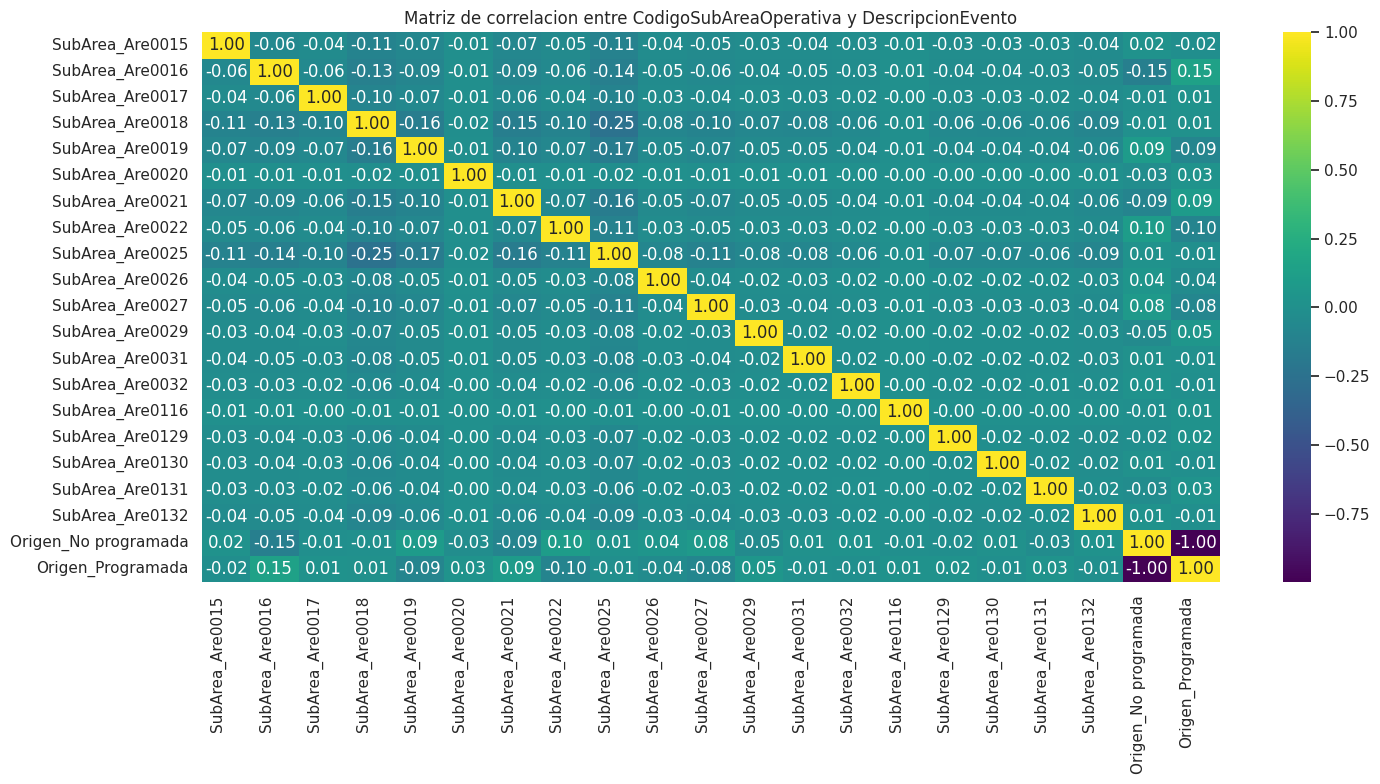

In [23]:
## Matriz de correlacion con respecto a subarea operativa

# Creo el mapa de calor
plt.figure(figsize=(15, 8))  # Adjust figure size if needed
sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f")  # Uso '.2f' para mostrar dos decimales en grafica
plt.title('Matriz de correlacion entre CodigoSubAreaOperativa y DescripcionEvento')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [46]:
data

,IdentificadorSuceso,FechaHoraInicio,FechaHoraFin,OrigenEvento,EnergiaNoAtendida,DescripcionEvento,CodigoSubAreaOperativa,FechaHoraInicio_timestamp,FechaHoraFin_timestamp,DescripcionEvento_Numerica,DuracionSegundos,Duracion,DuracionHoras,DuracionDias
0,S000020446,2022-08-10 22:17:00,2022-08-10 22:35:00,No programada,4200.0,Demanda no atendida por disparo del activo BL1...,Are0025,1660169820,1660170900,0,1080.0,0 days 00:18:00,0.300000,0.012500
1,S000020443,2022-08-10 00:13:00,2022-08-10 12:26:00,No programada,505600.0,Demanda no atendida por disparo del activo CHI...,Are0021,1660090380,1660134360,1,43980.0,0 days 12:13:00,12.216667,0.509028
2,S000020444,2022-08-10 02:14:00,2022-08-10 02:39:00,No programada,19510.0,Demanda no atendida por disparo del activo BL1...,Are0018,1660097640,1660099140,2,1500.0,0 days 00:25:00,0.416667,0.017361
3,S000020445,2022-08-10 21:56:00,2022-08-10 22:11:00,No programada,5500.0,Demanda no atendida por disparo del activo BL1...,Are0018,1660168560,1660169460,3,900.0,0 days 00:15:00,0.250000,0.010417
4,S000019673,2021-11-18 00:41:00,2021-11-18 02:54:00,No programada,18180.0,Demanda no atendida por disparo del activo LA ...,Are0021,1637196060,1637204040,4,7980.0,0 days 02:13:00,2.216667,0.092361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3674,S000021793,2023-10-25 18:25:00,2023-10-25 21:55:00,No programada,167400.0,Demanda no atendida por disparo del activo BL1...,Are0017,1698258300,1698270900,2863,12600.0,0 days 03:30:00,3.500000,0.145833
3675,S000021794,2023-10-25 21:41:00,2023-10-25 21:49:00,No programada,5510.0,Demanda no atendida por disparo del activo BL1...,Are0025,1698270060,1698270540,1049,480.0,0 days 00:08:00,0.133333,0.005556
3676,S000021792,2023-10-25 06:32:00,2023-10-25 15:37:00,Programada,172670.0,Demanda no atendida por trabajos en las consig...,Are0016,1698215520,1698248220,2864,32700.0,0 days 09:05:00,9.083333,0.378472
3677,S000021530,2023-08-22 07:08:00,2023-08-22 16:37:00,No programada,360000.0,Demanda no atendida por disparo del activo TPE...,Are0017,1692688080,1692722220,2865,34140.0,0 days 09:29:00,9.483333,0.395139


In [51]:
data = data_copia

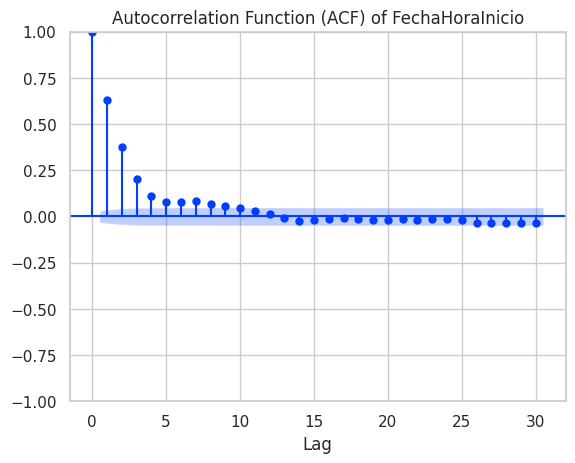

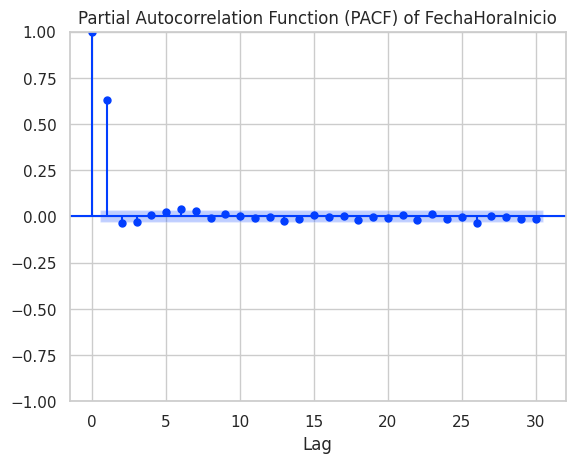

In [56]:
# Convert date columns to datetime objects
data['FechaHoraInicio'] = pd.to_datetime(data['FechaHoraInicio'], errors='coerce')
data['FechaHoraFin'] = pd.to_datetime(data['FechaHoraFin'], errors='coerce')
# # Extract a numerical representation of time (e.g., Unix timestamp)
# data['FechaHoraInicio_timestamp'] = data['FechaHoraInicio'].astype(np.int64) // 10**9
# data['FechaHoraFin_timestamp'] = data['FechaHoraFin'].astype(np.int64) // 10**9
## Autocorrelacion con fecha y hora de inicio del evento
# Esta mide la correlacion entre una serie temporal y sus valores pasados
# lags, indican el periodo de tiempo a evaluar
plot_acf(data['FechaHoraInicio_timestamp'].dropna(), lags=30)
plt.xlabel('Lag')
plt.title('Autocorrelation Function (ACF) of FechaHoraInicio')
plt.show()
## Autocorrelacion parcial con fecha y hora de inicio del evento
# Mide la correlacion entre una serie temporal y tiempos especificos
plot_pacf(data['FechaHoraInicio_timestamp'].dropna(), lags=30)
plt.xlabel('Lag')
plt.title('Partial Autocorrelation Function (PACF) of FechaHoraInicio')
plt.show()

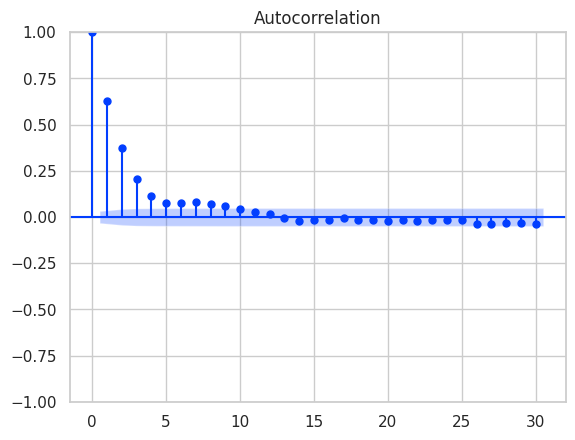

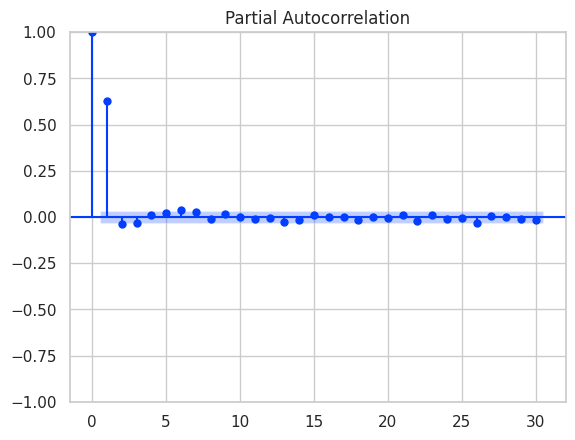

In [57]:
## Autocorrelacion con fecha y hora de fin del evento
plot_acf(data['FechaHoraFin'], lags=30)  # Adjust lags as needed
plt.show()
## Autocorrelacion parcial con fecha y hora de fin del evento
plot_pacf(data['FechaHoraFin'], lags=30)  # Adjust lags as needed
plt.show()

In [26]:
data_origen_desc = data.groupby(['OrigenEvento', 'DescripcionEvento']).size().sort_values(ascending=False)
data_origen_desc

OrigenEvento   DescripcionEvento                                                                                                                                                                                      
No programada  Demanda no atendida por bajas tensiones en la subestación EL BANCO 110 kV.                                                                                                                                 33
               Demanda no atendida por disparo del activo GRANADA - OCOA 1 115 kV, dejando sin tensión las S/Es radiales GRANADA 115 kV y SAN JOSE DEL GUAVIARE 115 kV.                                                   21
               Demanda no atendida por disparo del activo EL PASO - EL BANCO 1 110 kV dejando sin tensión la S/E radial EL BANCO 110 kV.                                                                                  19
               Demanda no atendida por disparo del activo FUNDACION - TFUNDACION - RIO CORDOBA 1 110 kV.                                                                                                                  18
               Demanda no atendida por disparo del activo EL PASO - EL COPEY 1 110 kV, dejando sin tensión las S/Es radiales EL PASO 110 kV y EL BANCO 110 kV.                                                            13
                                                                                                                                                                                                                          ..
               Demanda no atendida por disparo del activo BL1 TERMOZIPA A GRAN SABANA 115 kV, dejando sin tensión la subestación radial GRAN SABANA 115 kV.                                                                1
               Demanda no atendida por disparo del activo BL1 TERMOZIPA A SESQUILE 115 kV dejando sin tensión la S/E SESQUILE 115 kV temporalmente radial por condición operativa. El agente reporta falla en el STR.      1
               Demanda no atendida por disparo del activo BL1 TERMOZIPA A SESQUILE 115 kV dejando sin tensión la S/E SESQUILE 115 kV temporalmente radial por condición operativa. El agente reporta falla en el STR.      1
               Demanda no atendida por disparo del activo BL1 TERMOZIPA A SESQUILE 115 kV, dejando sin tensión la S/E SESQUILE 115 kV, temporalmente radial por condición operativa del sistema.                           1
               Demanda no atendida por disparo del activo BL1 SINCE A MAGANGUE 110 kV, dejando sin tensión las S/Es radiales MAGANGUE 110kV y MOMPOX 110 kV.                                                               1
Length: 2877, dtype: int64

In [27]:
# Tambien se puede realizar con label encoder de sklearn
# Crea un diccionario para mapear las categorías a valores numéricos
mapeo_categorias = {categoria: valor for valor, categoria in enumerate(data[
    'DescripcionEvento'].unique())}
# Aplica el mapeo a la columna 'DescripcionEvento'
data['DescripcionEvento_Numerica'] = data['DescripcionEvento'].map(mapeo_categorias)
# Imprime el DataFrame actualizado para verificar los cambios
data

,IdentificadorSuceso,FechaHoraInicio,FechaHoraFin,OrigenEvento,EnergiaNoAtendida,DescripcionEvento,CodigoSubAreaOperativa,FechaHoraInicio_timestamp,FechaHoraFin_timestamp,DescripcionEvento_Numerica
0,S000020446,2022-08-10 22:17:00,2022-08-10 22:35:00,No programada,4200.0,Demanda no atendida por disparo del activo BL1...,Are0025,1660169820,1660170900,0
1,S000020443,2022-08-10 00:13:00,2022-08-10 12:26:00,No programada,505600.0,Demanda no atendida por disparo del activo CHI...,Are0021,1660090380,1660134360,1
2,S000020444,2022-08-10 02:14:00,2022-08-10 02:39:00,No programada,19510.0,Demanda no atendida por disparo del activo BL1...,Are0018,1660097640,1660099140,2
3,S000020445,2022-08-10 21:56:00,2022-08-10 22:11:00,No programada,5500.0,Demanda no atendida por disparo del activo BL1...,Are0018,1660168560,1660169460,3
4,S000019673,2021-11-18 00:41:00,2021-11-18 02:54:00,No programada,18180.0,Demanda no atendida por disparo del activo LA ...,Are0021,1637196060,1637204040,4
...,...,...,...,...,...,...,...,...,...,...
3674,S000021793,2023-10-25 18:25:00,2023-10-25 21:55:00,No programada,167400.0,Demanda no atendida por disparo del activo BL1...,Are0017,1698258300,1698270900,2863
3675,S000021794,2023-10-25 21:41:00,2023-10-25 21:49:00,No programada,5510.0,Demanda no atendida por disparo del activo BL1...,Are0025,1698270060,1698270540,1049
3676,S000021792,2023-10-25 06:32:00,2023-10-25 15:37:00,Programada,172670.0,Demanda no atendida por trabajos en las consig...,Are0016,1698215520,1698248220,2864
3677,S000021530,2023-08-22 07:08:00,2023-08-22 16:37:00,No programada,360000.0,Demanda no atendida por disparo del activo TPE...,Are0017,1692688080,1692722220,2865


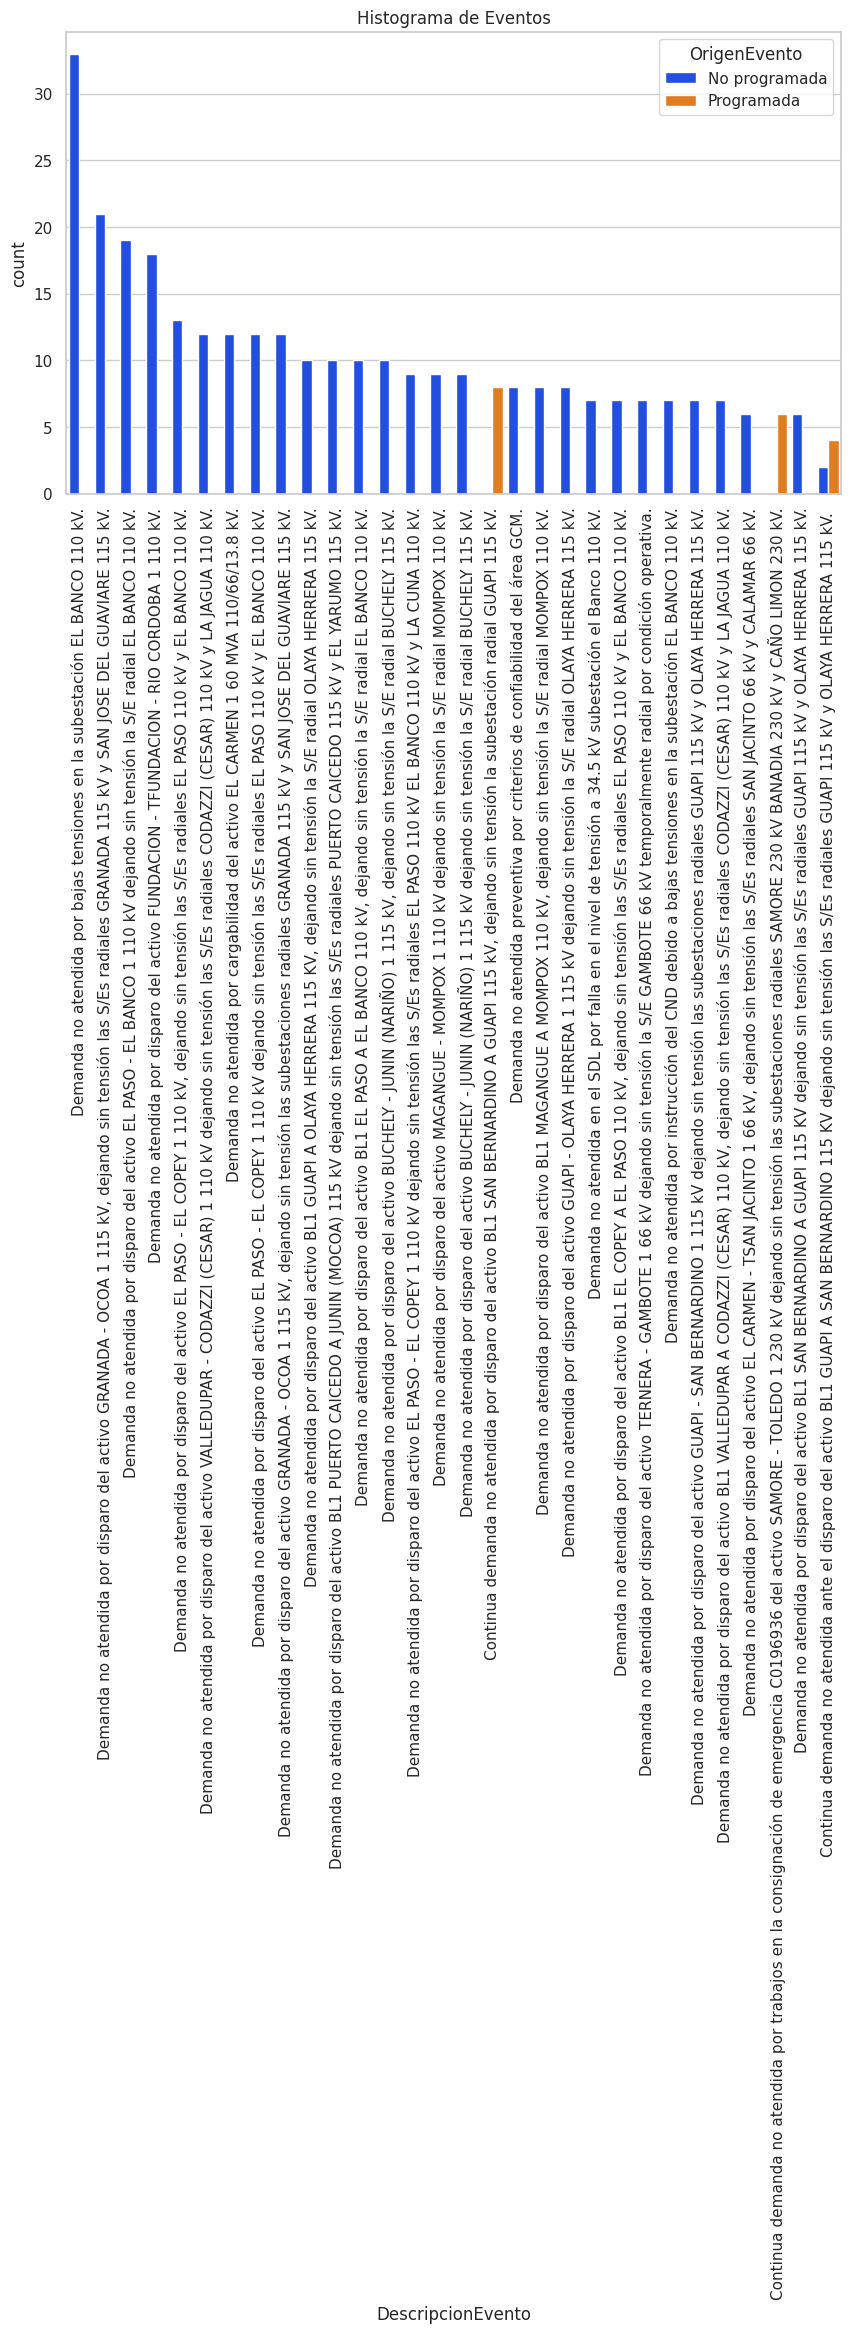

In [28]:
category_counts = data['DescripcionEvento'].value_counts()
category_order = category_counts.index
top_30_categories = category_counts.head(30).index
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura si es necesario
sns.countplot(data=data, x="DescripcionEvento", hue="OrigenEvento", order=top_30_categories)
plt.xticks(rotation=90)  # Rota las etiquetas del eje x para mejor legibilidad
plt.title('Histograma de Eventos')
plt.show()

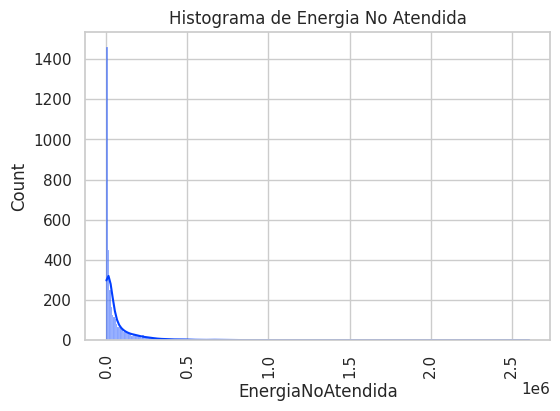

In [60]:
plt.figure(figsize=(6, 4))  # Ajusta el tamaño de la figura si es necesario
sns.histplot(data=data, x="EnergiaNoAtendida", kde=True)
plt.xticks(rotation=90)  # Rota las etiquetas del eje x para mejor legibilidad
plt.title('Histograma de Energia No Atendida')
plt.show()

**Analisis de serie de tiempo**

In [31]:
## Analisis temporal de eventos
data['DuracionSegundos'] = (data['FechaHoraFin'] - data['FechaHoraInicio']).dt.total_seconds()
data['DuracionSegundos'].sort_values(ascending=False)

,DuracionSegundos
3573,142260.0
412,127680.0
3492,111180.0
3045,106200.0
1706,104820.0
...,...
1364,0.0
1894,-480.0
1325,NaN
1336,NaN


In [32]:
data['Duracion'] = (data['FechaHoraFin'] - data['FechaHoraInicio'])
data['DuracionHoras'] = data['Duracion'].dt.total_seconds() / 3600
data['DuracionHoras'].sort_values(ascending=False)

,DuracionHoras
3573,39.516667
412,35.466667
3492,30.883333
3045,29.500000
1706,29.116667
...,...
1364,0.000000
1894,-0.133333
1325,NaN
1336,NaN


In [62]:
data['Duracion'] = (data['FechaHoraFin'] - data['FechaHoraInicio'])
data['DuracionHoras'] = data['Duracion'].dt.total_seconds() / 3600
data['DuracionDias'] = data['Duracion'].dt.total_seconds() / (3600*24)
data['DuracionDias'].sort_values(ascending=False)

,DuracionDias
3573,1.646528
412,1.477778
3492,1.286806
3045,1.229167
1706,1.213194
...,...
837,0.000694
1843,0.000694
756,0.000000
1364,0.000000


In [64]:
## Sumatoria de registros
print(f"""El total de energia no atendida desde 2020-01-31 hasta 2024-04-30,
       fue de {data['EnergiaNoAtendida'].sum()} kWh en una duracion
       de {round(data['DuracionDias'].sum(),4)} dias, correspondiente a
       {round(data['DuracionHoras'].sum(), 4)} horas""")

El total de energia no atendida desde 2020-01-31 hasta 2024-04-30, 
       fue de 234200679.99 kWh en una duracion 
       de 664.7632 dias, correspondiente a
       15954.3167 horas


In [34]:
## Estadisticos descriptivos
print(f"La duracion promedio  de los eventos en horas fue de: {round(data['DuracionHoras'].mean(), 5)}")
print(f"La mediana de la duracion de los eventos en horas fue de: {round(data['DuracionHoras'].median(), 5)}")
print(f"La desviacion estandar de los eventos en horas fue de: {round(data['DuracionHoras'].std(), 5)}")

La duracion promedio  de los eventos en horas fue de: 4.34246
La mediana de la duracion de los eventos en horas fue de: 1.66667
La desviacion estandar de los eventos en horas fue de: 5.47447


In [35]:
## Calculo percentiles
print("Percentiles para duracion de eventos en horas")
print(f"El percentil 25% es igual a {data['DuracionHoras'].quantile(q=0.25)}")
print(f"El percentil 50% es igual a {round(data['DuracionHoras'].quantile(q=0.5), 5)}")
print(f"El percentil 75% es igual a {round(data['DuracionHoras'].quantile(q=0.75), 5)}")

Percentiles para duracion de eventos en horas
El percentil 25% es igual a 0.3
El percentil 50% es igual a 1.66667
El percentil 75% es igual a 7.63333


Ejercicio practico

1 - Descargar bases de datos sobre hurtos

2 - Realizar EDA

3 - Calcular autocorrelacion

4 - Identificar barrios con la mayor y la menor cantidad de registros